# MotoDB: Wholesale Vehicle Market Analytics
**Objective:** To extract, clean, and analyze wholesale vehicle auction data to identify market trends, vehicle depreciation curves, and high-profit inventory segments. 

This project is divided into two phases:
1. **Data Engineering:** Sanitizing dirty auction data, handling missing values, and engineering target metrics.
2. **Exploratory Data Analysis (EDA):** Visualizing market trends and building KPI dashboards.

In [ ]:
import pyodbc
import pandas as pd

# 1. Set server and database names
server_name = 'localhost' 
database_name = 'MotoDB'

# 2. Build the connection string
conn_str = (
    f"DRIVER={{ODBC Driver 17 for SQL Server}};"
    f"SERVER={server_name};"
    f"DATABASE={database_name};"
    f"Trusted_Connection=yes;"
)

try:
    # 3. Connect to SQL Server
    print("Connecting to MotoDB...")
    conn = pyodbc.connect(conn_str)
    print("Connection successful!\n")

    # 4. Load the database table into Python
    query = "SELECT * FROM VehicleSales;" # Replace with your actual table name if different
    
    # Using pandas is the standard way to 'load' a database for analysis
    df = pd.read_sql(query, conn)

    # 5. Display the first few rows to prove it worked
    print(df.head())

except Exception as e:
    print(f"An error occurred: {e}")

finally:
    # Always close the connection when you are done
    if 'conn' in locals():
        conn.close()

Connecting to MotoDB...
Connection successful!



C:\Users\hemak\AppData\Local\Temp\ipykernel_20404\847070403.py:30: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


   Id  Year   Make                Model        Trim   Body Transmission  \
0   2  2015    Kia              Sorento          LX    SUV    automatic   
1   3  2015    Kia              Sorento          LX    SUV    automatic   
2   4  2014    BMW             3 Series  328i SULEV  Sedan    automatic   
3   5  2015  Volvo                  S60          T5  Sedan    automatic   
4   6  2014    BMW  6 Series Gran Coupe        650i  Sedan    automatic   

                 VIN State  ConditionValue  Odometer  Color Interior  \
0  5xyktca69fg566472    ca             5.0   16639.0  white    black   
1  5xyktca69fg561319    ca             5.0    9393.0  white    beige   
2  wba3c1c51ek116351    ca            45.0    1331.0   gray    black   
3  yv1612tb4f1310987    ca            41.0   14282.0  white    black   
4  wba6b2c57ed129731    ca            43.0    2641.0   gray    black   

                                   Seller      MMR  SellingPrice  \
0                 kia motors america  inc  20500

### 🔍 Step 1: Initial Data Profiling
Before altering the dataset, we must understand its raw structure. Here we check the dataset's shape, data types, and identify where the highest concentration of missing (`NaN`) values exists. This informs our imputation strategy.

In [28]:
# --- STEP 1: DATA INSPECTION ---

# 1. Check the shape (Rows and Columns)
print(f"Dataset Shape: {df.shape[0]} rows and {df.shape[1]} columns\n")

# 2. Check Data Types and Non-Null Counts
print("--- Column Info & Datatypes ---")
df.info()

# 3. Quick check for missing values (Nulls)
print("\n--- Missing Values Count ---")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0].sort_values(ascending=False))

# 4. Statistical Summary for numerical columns
display(df.describe())

Dataset Shape: 558837 rows and 17 columns

--- Column Info & Datatypes ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Id              558837 non-null  int64         
 1   Year            558837 non-null  int64         
 2   Make            548536 non-null  object        
 3   Model           548438 non-null  object        
 4   Trim            548186 non-null  object        
 5   Body            545642 non-null  object        
 6   Transmission    493485 non-null  object        
 7   VIN             558833 non-null  object        
 8   State           558837 non-null  object        
 9   ConditionValue  547017 non-null  float64       
 10  Odometer        558743 non-null  float64       
 11  Color           558088 non-null  object        
 12  Interior        558088 non-null  object        
 13  Seller        

,Id,Year,ConditionValue,Odometer,MMR,SellingPrice,SaleDate
count,558837.000000,558837.000000,547017.000000,558743.000000,558799.000000,558825.000000,558799
mean,279420.000000,2010.038927,30.672365,68320.017767,13769.377495,13611.358810,2015-03-06 00:09:10.521385472
min,2.000000,1982.000000,1.000000,1.000000,25.000000,1.000000,2014-01-01 01:15:00
25%,139711.000000,2007.000000,23.000000,28371.000000,7100.000000,6900.000000,2015-01-20 18:00:00
50%,279420.000000,2012.000000,35.000000,52254.000000,12250.000000,12100.000000,2015-02-12 19:20:00
75%,419129.000000,2013.000000,42.000000,99109.000000,18300.000000,18200.000000,2015-05-21 19:00:00
max,558838.000000,2015.000000,49.000000,999999.000000,182000.000000,230000.000000,2015-07-20 19:30:00
std,161322.490529,3.966864,13.402832,53398.542821,9679.967174,9749.501628,NaN


In [29]:
# --- Inspect Transmission ---
print(f"Total Unique Transmissions: {df['Transmission'].nunique()}")
print(df['Transmission'].dropna().unique())

Total Unique Transmissions: 4
['automatic' 'manual' 'Sedan' 'sedan']


In [30]:
# --- Inspect Body Styles ---
print(f"Total Unique Body Styles: {df['Body'].nunique()}")
# Printing the first 50 unique body styles so it doesn't flood your screen
print(df['Body'].dropna().unique()[:50])

Total Unique Body Styles: 87
['SUV' 'Sedan' 'Convertible' 'Coupe' 'Wagon' 'Hatchback' 'Crew Cab'
 'G Coupe' 'G Sedan' 'Elantra Coupe' 'Genesis Coupe' 'Minivan' 'Van'
 'Double Cab' 'CrewMax Cab' 'Access Cab' 'King Cab' 'SuperCrew'
 'CTS Coupe' 'Extended Cab' 'E-Series Van' 'SuperCab' 'Regular Cab'
 'G Convertible' 'Koup' 'Quad Cab' 'CTS-V Coupe' 'sedan' 'G37 Convertible'
 'Club Cab' 'Xtracab' 'Q60 Convertible' 'CTS Wagon' 'convertible'
 'G37 Coupe' 'Mega Cab' 'Cab Plus 4' 'Q60 Coupe' 'Cab Plus'
 'Beetle Convertible' 'TSX Sport Wagon' 'Promaster Cargo Van'
 'GranTurismo Convertible' 'CTS-V Wagon' 'Ram Van' 'minivan' 'suv'
 'Transit Van' 'Navitgation' 'van']


In [31]:
# --- Inspect Car Makes (Brands) ---
print(f"Total Unique Makes: {df['Make'].nunique()}")
print(df['Make'].dropna().unique())

Total Unique Makes: 96
['Kia' 'BMW' 'Volvo' 'Nissan' 'Chevrolet' 'Audi' 'Ford' 'Hyundai' 'Buick'
 'Cadillac' 'Acura' 'Lexus' 'Infiniti' 'Jeep' 'Mercedes-Benz' 'Mitsubishi'
 'Mazda' 'MINI' 'Land Rover' 'Lincoln' 'lincoln' 'Jaguar' 'Volkswagen'
 'Toyota' 'Subaru' 'Scion' 'Porsche' 'bmw' 'Dodge' 'FIAT' 'Chrysler'
 'ford' 'Ferrari' 'Honda' 'GMC' 'mitsubishi' 'Ram' 'smart' 'chevrolet'
 'Bentley' 'chrysler' 'pontiac' 'Pontiac' 'Saturn' 'Maserati' 'Mercury'
 'HUMMER' 'landrover' 'cadillac' 'land rover' 'mercedes' 'mazda' 'toyota'
 'lexus' 'gmc truck' 'honda' 'nissan' 'porsche' 'Saab' 'Suzuki' 'dodge'
 'subaru' 'Oldsmobile' 'oldsmobile' 'hyundai' 'jeep' 'Isuzu' 'dodge tk'
 'Geo' 'acura' 'volkswagen' 'suzuki' 'kia' 'audi' 'Rolls-Royce' 'gmc'
 'maserati' 'mazda tk' 'mercury' 'buick' 'hyundai tk' 'mercedes-b' 'vw'
 'Daewoo' 'chev truck' 'ford tk' 'plymouth' 'Plymouth' 'ford truck'
 'Tesla' 'airstream' 'dot' 'Aston Martin' 'Fisker' 'Lamborghini' 'Lotus']


In [32]:
# --- Inspect Car Models ---
print(f"Total Unique Models: {df['Model'].nunique()}")

# 1. Extract all unique models and drop the nulls
all_models = df['Model'].dropna().unique()

# 2. Sort them alphabetically for easier reading
all_models.sort()

# 3. Print every single one in a clean, numbered list
print("\n--- All Unique Models ---")
for i, model in enumerate(all_models, start=1):
    print(f"{i}. {model}")

Total Unique Models: 973

--- All Unique Models ---
1. 1
2. 1 Series
3. 1500
4. 190-Class
5. 2 Series
6. 200
7. 200SX
8. 2500
9. 3
10. 3 Series
11. 3 Series Gran Turismo
12. 300
13. 300-Class
14. 3000GT
15. 300M
16. 300ZX
17. 300e
18. 320i
19. 323i
20. 328i
21. 350
22. 3500
23. 350Z
24. 350z
25. 360
26. 370Z
27. 4 Series
28. 4 Series Gran Coupe
29. 400-Class
30. 420-Class
31. 420sel
32. 42c
33. 458 Italia
34. 4Runner
35. 5 Series
36. 5 Series Gran Turismo
37. 500
38. 500-Class
39. 500L
40. 500e
41. 6
42. 6 Series
43. 6 Series Gran Coupe
44. 626
45. 7
46. 7 Series
47. 750i
48. 750li
49. 750lxi
50. 8 Series
51. 850
52. 9-2X
53. 9-3
54. 9-5
55. 9-7X
56. 911
57. 940
58. 960
59. A3
60. A4
61. A5
62. A6
63. A7
64. A8
65. ATS
66. Acadia
67. Accent
68. Accord
69. Accord Crosstour
70. Accord Hybrid
71. Achieva
72. ActiveHybrid 5
73. ActiveHybrid 7
74. ActiveHybrid X6
75. Aerio
76. Alero
77. Altima
78. Altima Hybrid
79. Amanti
80. Amigo
81. Armada
82. Ascender
83. Aspen
84. Aspire
85. Astra
86. 

In [33]:
# --- Inspect Car Trims ---
print(f"Total Unique Trims: {df['Trim'].nunique()}")

# 1. Extract all unique trims and drop the nulls
all_trims = df['Trim'].dropna().unique()

# 2. Sort them alphabetically for easier reading
all_trims.sort()

# 3. Print every single one in a clean, numbered list
print("\n--- All Unique Trims ---")
for i, trim in enumerate(all_trims, start=1):
    print(f"{i}. {trim}")

Total Unique Trims: 1963

--- All Unique Trims ---
1. !
2. & coun fwd
3. & coun fwd limited
4. & coun fwd lx
5. & country lx
6. (1999.5) XE
7. +
8. 1
9. 1.6
10. 1.6 Base
11. 1.6 S
12. 1.6 S Plus
13. 1.6 SL
14. 1.6 SV
15. 1.8
16. 1.8 Base
17. 1.8 Krom
18. 1.8 S
19. 1.8 S Krom Edition
20. 1.8 SL
21. 1.8 TFSI Premium
22. 1.8 TFSI Premium Plus
23. 1.8T
24. 1.8T Avant quattro
25. 1.8T Classic
26. 1.8T quattro
27. 1.9
28. 10th Anniversary
29. 128i
30. 128i SULEV
31. 135i
32. 135is
33. 150 Low Roof
34. 1500
35. 1500 4x2
36. 1500 4x2 cr sle
37. 1500 4x2 cr sle1
38. 1500 4x2 ex sle
39. 1500 4x2 slt
40. 1500 4x4 cr slt
41. 1500 4x4 ex sle
42. 1500 4x4 v8 slt
43. 1500 High Roof
44. 1500 LS
45. 1500 LT
46. 1500 LT1
47. 1500 LTZ
48. 1500 Low Roof
49. 1500 Maxi
50. 1500 S
51. 1500 SLE
52. 1500 SLT
53. 1500 SV
54. 1500 awd cr denali
55. 1500 base
56. 1500 lramie slt
57. 1794
58. 1794 FFV
59. 180hp
60. 180hp quattro
61. 190E 2.3
62. 1LS Fleet
63. 1LT
64. 1LT Fleet
65. 1SS
66. 2
67. 2+2
68. 2.0 S
69. 2

In [34]:
# --- Inspect Colors and Interiors ---
print("--- Exterior Colors ---")
print(df['Color'].dropna().unique())

print("\n--- Interior Colors ---")
print(df['Interior'].dropna().unique())

--- Exterior Colors ---
['white' 'gray' 'black' 'red' 'silver' 'blue' 'brown' 'beige' 'purple'
 'burgundy' '—' 'gold' 'yellow' 'green' 'charcoal' 'orange' 'off-white'
 'turquoise' 'pink' 'lime' '4802' '9410' '1167' '2172' '14872' '12655'
 '15719' '6388' '16633' '11034' '2711' '6864' '339' '18384' '9887' '9837'
 '20379' '20627' '721' '6158' '2817' '5705' '18561' '2846' '9562' '5001']

--- Interior Colors ---
['black' 'beige' 'tan' '—' 'gray' 'brown' 'burgundy' 'white' 'silver'
 'off-white' 'blue' 'red' 'yellow' 'green' 'purple' 'orange' 'gold']


In [35]:
# --- Inspect Condition Scores ---
print(f"Total Unique Condition Scores: {df['ConditionValue'].nunique()}")
# Sorting them to see if there are weird values (like 45.0 instead of 4.5)
condition_scores = df['ConditionValue'].dropna().unique()
condition_scores.sort()
print(condition_scores)

Total Unique Condition Scores: 41
[ 1.  2.  3.  4.  5. 11. 12. 13. 14. 15. 16. 17. 18. 19. 21. 22. 23. 24.
 25. 26. 27. 28. 29. 31. 32. 33. 34. 35. 36. 37. 38. 39. 41. 42. 43. 44.
 45. 46. 47. 48. 49.]


In [36]:
# --- Inspect Continuous & High Cardinality Data ---
print("--- Unique Value Counts ---")
print(f"VINs: {df['VIN'].nunique()}")
print(f"Odometer readings: {df['Odometer'].nunique()}")
print(f"MMR estimates: {df['MMR'].nunique()}")
print(f"Selling Prices: {df['SellingPrice'].nunique()}")
print(f"Sale Dates: {df['SaleDate'].nunique()}")

# Show a tiny 5-row sample to see what the raw data looks like
print("\n--- Data Sample ---")
display(df[['VIN', 'Odometer', 'MMR', 'SellingPrice', 'SaleDate']].dropna().sample(5))

--- Unique Value Counts ---
VINs: 550297
Odometer readings: 172278
MMR estimates: 1101
Selling Prices: 1887
Sale Dates: 3745

--- Data Sample ---


,VIN,Odometer,MMR,SellingPrice,SaleDate
143124,3gnfc16j57g318152,147106.0,9075.0,9800.0,2015-01-13 20:30:00
467480,1fmfu17l44la13662,197872.0,2725.0,2800.0,2015-05-26 20:00:00
328822,wvwak73cx6p053074,94200.0,3975.0,3700.0,2015-02-17 18:00:00
444724,2g1fa1e32e9204711,3999.0,19200.0,21100.0,2015-06-03 19:30:00
525727,wddgf5eb1br162258,22587.0,19050.0,19750.0,2015-06-11 00:00:00


In [37]:
# Find all rows where Transmission is mistakenly labeled as 'sedan'
bad_transmissions = df[df['Transmission'].str.lower() == 'sedan']

print(f"Total rows with this error: {len(bad_transmissions)}")
display(bad_transmissions[['Make', 'Model', 'Trim', 'Body', 'Year','Transmission']])

Total rows with this error: 26


,Make,Model,Trim,Body,Year,Transmission
408161,Volkswagen,Jetta,SE PZEV w/Connectivity,Navitgation,2015,Sedan
417835,Volkswagen,Jetta,SE PZEV w/Connectivity,Navitgation,2015,Sedan
421289,Volkswagen,Jetta,SE PZEV w/Connectivity,Navitgation,2015,Sedan
424161,Volkswagen,Jetta,SE PZEV w/Connectivity,Navitgation,2015,Sedan
427040,Volkswagen,Jetta,SE PZEV w/Connectivity,Navitgation,2015,Sedan
427043,Volkswagen,Jetta,SE PZEV w/Connectivity,Navitgation,2015,Sedan
434424,Volkswagen,Jetta,SE PZEV w/Connectivity,Navitgation,2015,Sedan
444501,Volkswagen,Jetta,SE PZEV w/Connectivity,Navitgation,2015,Sedan
453794,Volkswagen,Jetta,SE PZEV w/Connectivity,Navitgation,2015,Sedan
461597,Volkswagen,Jetta,SE PZEV w/Connectivity,Navitgation,2015,Sedan


### ⚙️ Step 2: Correcting Data-Shift Errors
During our initial inspection, we noticed values like "Sedan" appearing in the `Transmission` column. This is a classic data-shift error caused by misaligned CSV formatting during the database import. We will clean this by standardizing the text and replacing invalid entries.

In [38]:
# --- STEP 2: FIX TRANSMISSION ERRORS ---

# 1. Standardize the column to lowercase first so we catch 'Sedan', 'sedan', 'SEDAN'
df['Transmission'] = df['Transmission'].astype(str).str.lower().str.strip()

# 2. Replace the shifted data with 'unknown'
df['Transmission'] = df['Transmission'].replace(['sedan', 'nan'], 'automatic')

# 3. Verify the fix
print("Cleaned Unique Transmissions:")
print(df['Transmission'].unique())

Cleaned Unique Transmissions:
['automatic' 'none' 'manual']


### 🏷️ Step 2b: Brand Normalization (Make)
Auction data is notorious for inconsistent brand naming (e.g., `ford`, `Ford`, `ford tk`). To ensure our brand-level analytics are accurate, we apply text standardization and dictionary-based mapping to consolidate these variations into single, unified corporate entities.

In [39]:
# --- STEP 2b: STANDARDIZE CAR MAKES (BRANDS) ---

print(f"Total Unique Makes before cleaning: {df['Make'].nunique()}")

# 1. Convert everything to lowercase and strip hidden spaces
df['Make'] = df['Make'].astype(str).str.lower().str.strip()

# 2. Create a dictionary to fix specific auction typos and abbreviations
make_corrections = {
    'landrover': 'land rover',
    'mercedes-b': 'mercedes-benz',
    'mercedes': 'mercedes-benz',
    'mazda tk': 'mazda',
    'ford tk': 'ford',
    'ford truck': 'ford',
    'gmc truck': 'gmc',
    'vw': 'volkswagen'
}

# Apply the corrections
df['Make'] = df['Make'].replace(make_corrections)

# 3. Convert back to Title Case (e.g., 'ford' -> 'Ford')
df['Make'] = df['Make'].str.title()

# 4. Fix Acronyms that Title Case messes up (e.g., 'Bmw' -> 'BMW')
acronym_fixes = {
    'Bmw': 'BMW',
    'Gmc': 'GMC',
    'Fiat': 'FIAT',
    'Mini': 'MINI',
    'Vw': 'VW'
}
df['Make'] = df['Make'].replace(acronym_fixes)

# 5. Verify the fix
cleaned_makes = df['Make'].dropna().unique()
cleaned_makes.sort()

print(f"Total Unique Makes after cleaning: {df['Make'].nunique()}")
print("\n--- Cleaned Brand List ---")
print(cleaned_makes.tolist())

Total Unique Makes before cleaning: 96
Total Unique Makes after cleaning: 59

--- Cleaned Brand List ---
['Acura', 'Airstream', 'Aston Martin', 'Audi', 'BMW', 'Bentley', 'Buick', 'Cadillac', 'Chev Truck', 'Chevrolet', 'Chrysler', 'Daewoo', 'Dodge', 'Dodge Tk', 'Dot', 'FIAT', 'Ferrari', 'Fisker', 'Ford', 'GMC', 'Geo', 'Honda', 'Hummer', 'Hyundai', 'Hyundai Tk', 'Infiniti', 'Isuzu', 'Jaguar', 'Jeep', 'Kia', 'Lamborghini', 'Land Rover', 'Lexus', 'Lincoln', 'Lotus', 'MINI', 'Maserati', 'Mazda', 'Mercedes-Benz', 'Mercury', 'Mitsubishi', 'Nissan', 'None', 'Oldsmobile', 'Plymouth', 'Pontiac', 'Porsche', 'Ram', 'Rolls-Royce', 'Saab', 'Saturn', 'Scion', 'Smart', 'Subaru', 'Suzuki', 'Tesla', 'Toyota', 'Volkswagen', 'Volvo']


In [40]:
# If you prefer to guess based on the majority:
most_common_trans = df['Transmission'].mode()[0] # This will be 'automatic'
df['Transmission'] = df['Transmission'].replace(['sedan', 'nan', 'none'], most_common_trans)

### 🧹 Step 3: Body Style Categorization
The raw data contains over 80 hyper-specific and messy body styles (e.g., "CrewMax Cab", "Koup"). We use a programmatic keyword-extraction function to collapse these fragments into 8 primary industry segments (SUV, Sedan, Pickup, Van, Hatchback, Coupe, Wagon, Convertible).

In [49]:
# --- STEP 3: STANDARDIZE BODY STYLES ---

def clean_body_style(text):
    # Handle missing values first
    if pd.isna(text):
        return 'Unknown'
    
    # Standardize to lowercase for easy searching
    text = str(text).lower().strip()
    
    # 1. Trucks / Pickups (Catches Crew Cab, Quad Cab, SuperCrew, etc.)
    if 'cab' in text or 'crew' in text:
        return 'Pickup'
    
    # 2. Vans (Catches Minivan, Promaster Cargo Van, Transit Van, etc.)
    if 'van' in text:
        return 'Van'
    
    # 3. Convertibles
    if 'convertible' in text:
        return 'Convertible'
    
    # 4. Coupes (Catches G Coupe, Koup, CTS-V Coupe, etc.)
    if 'coupe' in text or 'koup' in text:
        return 'Coupe'
    
    # 5. Wagons (Catches TSX Sport Wagon, CTS Wagon, etc.)
    if 'wagon' in text:
        return 'Wagon'
    
    # 6. SUVs
    if 'suv' in text:
        return 'SUV'
    
    # 7. Sedans (Catches G Sedan, etc.)
    if 'sedan' in text:
        return 'Sedan'
        
    # 8. Hatchbacks
    if 'hatchback' in text:
        return 'Hatchback'
        
    # 9. Fix absolute errors (Like 'navitgation')
    if text == 'navitgation':
        return 'Unknown'
        
    # Fallback for anything else that might have slipped through
    return text.title()

# Apply the cleaning function to the dataset
df['Body'] = df['Body'].apply(clean_body_style)

# Verify the fix
print("✅ Cleaned Unique Body Styles:")
print(df['Body'].unique())

# Show the count of each new clean category
print("\n--- Volume per Cleaned Category ---")
print(df['Body'].value_counts())

✅ Cleaned Unique Body Styles:
['SUV' 'Sedan' 'Convertible' 'Coupe' 'Wagon' 'Hatchback' 'Pickup' 'Van']

--- Volume per Cleaned Category ---
Body
Sedan          248797
SUV            144589
Pickup          47669
Van             32153
Hatchback       26237
Coupe           20277
Wagon           16271
Convertible     10934
Name: count, dtype: int64


In [42]:
# --- STEP 4: INVESTIGATE 'UNKNOWN' BODY STYLES ---

# 1. Filter the dataframe to only show rows where Body is 'Unknown'
unknown_bodies = df[df['Body'] == 'Unknown']

print(f"Total 'Unknown' Body Styles remaining: {len(unknown_bodies)}\n")

# 2. Find the most common Models that are currently labeled as Unknown
# This tells us exactly which specific models we need to manually fix!
print("--- Top 15 Models missing a Body Style ---")
print(unknown_bodies['Model'].value_counts().head(15))

# 3. Display a random sample to see the raw data context (Make, Model, Trim)
print("\n--- Sample of Unknown Data ---")
display(unknown_bodies[['Make', 'Model', 'Trim', 'Body']].sample(min(10, len(unknown_bodies))))

Total 'Unknown' Body Styles remaining: 13221

--- Top 15 Models missing a Body Style ---
Model
pacifica    148
galant      100
gx           98
hhr          92
grand        86
pilot        82
range        79
srx          76
explorer     74
f150         62
corvette     62
wrangler     61
forester     58
1500         54
350z         52
Name: count, dtype: int64

--- Sample of Unknown Data ---


,Make,Model,Trim,Body
72818,None,None,None,Unknown
145730,None,None,None,Unknown
129543,None,None,None,Unknown
329594,None,None,None,Unknown
205598,None,None,None,Unknown
541183,None,None,None,Unknown
165937,None,None,None,Unknown
131451,None,None,None,Unknown
232926,None,None,None,Unknown
507954,None,None,None,Unknown


### 🎯 Step 5: Targeted Data Imputation
Some high-volume vehicles (like the Ford "F150" or Chrysler "Pacifica") bypassed our keyword filter because their marketing names do not contain words like "Truck" or "Van". Here, we use a manual dictionary mapping to hard-code the correct body styles for these specific top-selling models.

In [43]:
# --- STEP 5: MANUAL BODY STYLE OVERRIDES ---

# 1. Create a dictionary of the known missing models and their correct body styles
model_to_body_map = {
    'pacifica': 'Van',       # Chrysler Pacifica
    'galant': 'Sedan',       # Mitsubishi Galant
    'gx': 'SUV',             # Lexus GX
    'hhr': 'Wagon',          # Chevrolet HHR
    'grand': 'SUV',          # Usually Jeep Grand Cherokee (Grand Caravan was caught by 'van')
    'pilot': 'SUV',          # Honda Pilot
    'range': 'SUV',          # Range Rover
    'srx': 'SUV',            # Cadillac SRX
    'explorer': 'SUV',       # Ford Explorer
    'f150': 'Pickup',        # Ford F-150
    'corvette': 'Coupe',     # Chevy Corvette
    'wrangler': 'SUV',       # Jeep Wrangler
    'forester': 'SUV',       # Subaru Forester
    '1500': 'Pickup',        # Silverado 1500, Ram 1500, Sierra 1500
    '350z': 'Coupe'          # Nissan 350Z
}

# 2. Apply the dictionary to the dataframe
# We only overwrite rows where the Body is currently 'Unknown'
for model_keyword, correct_body in model_to_body_map.items():
    
    # Create a rule: "If Body is Unknown AND the Model contains our keyword"
    mask = (df['Body'] == 'Unknown') & (df['Model'].str.contains(model_keyword, case=False, na=False))
    
    # Apply the correct body style to those specific rows
    df.loc[mask, 'Body'] = correct_body

# 3. Check our progress
remaining_unknowns = df[df['Body'] == 'Unknown']
print(f"✅ Fix Applied!")
print(f"Remaining 'Unknown' Body Styles: {len(remaining_unknowns)}")

# Look at the top 5 left to see if we need another pass (optional)
if len(remaining_unknowns) > 0:
    print("\n--- Next Top 5 remaining (If any) ---")
    print(remaining_unknowns['Model'].value_counts().head(11964))

✅ Fix Applied!
Remaining 'Unknown' Body Styles: 11990

--- Next Top 5 remaining (If any) ---
Model
gr         51
cx-7       49
lr3        47
e150       45
c230wz     45
           ..
350         1
carrera     1
cruze       1
c230        1
rrs         1
Name: count, Length: 187, dtype: int64


In [44]:
# --- STEP 5b: EXTENDED MANUAL OVERRIDES ---

extended_model_map = {
    'cx-7': 'SUV',       # Mazda CX-7
    'lr3': 'SUV',        # Land Rover LR3
    'e150': 'Van',       # Ford E-150
    'c230wz': 'Sedan',   # Mercedes C-Class variation
    'sl55': 'Convertible',# Mercedes SL55 AMG
    'cruze': 'Sedan',    # Chevy Cruze
    'bronco': 'SUV',     # Ford Bronco
    'uplandr': 'Van'     # Chevy Uplander
    # Note: 'gr' and '350' are ignored because they are too ambiguous.
}

for model_keyword, correct_body in extended_model_map.items():
    mask = (df['Body'] == 'Unknown') & (df['Model'].str.contains(model_keyword, case=False, na=False))
    df.loc[mask, 'Body'] = correct_body

remaining_unknowns = df[df['Body'] == 'Unknown']
print(f"✅ Extended Fix Applied!")
print(f"Remaining 'Unknown' Body Styles: {len(remaining_unknowns)}")

✅ Extended Fix Applied!
Remaining 'Unknown' Body Styles: 11800


### 🗑️ Step 6: Critical Data Purge & Final Imputation
To prevent statistical bias, we must drop rows missing our core financial targets (`SellingPrice`, `MMR`). Imputing (guessing) prices ruins the integrity of the analysis. For minor gaps in continuous variables (like `Odometer`), we use median imputation. 

Finally, we engineer our primary KPI: **`Market_Delta`** (Selling Price - MMR).

In [45]:
# --- STEP 6: ELIMINATING NON-ESSENTIAL / UNUSABLE ROWS ---

print(f"Total rows before purge: {len(df)}")

# 1. Drop rows missing critical financial and identification data
# If we don't have the price, we can't calculate profit. If we don't have the Make, we can't analyze brands.
essential_columns = ['SellingPrice', 'MMR', 'Make', 'Model']
df = df.dropna(subset=essential_columns)

# 2. Drop the remaining 'Unknown' Body Styles
# We mapped everything we safely could. The rest (like 'gr' or '350') are too ambiguous to keep.
df = df[df['Body'] != 'Unknown']

# 3. Fill the less critical missing data (Odometer and Condition)
df['Odometer'] = df['Odometer'].fillna(df['Odometer'].median())
df['ConditionValue'] = pd.to_numeric(df['ConditionValue'], errors='coerce').fillna(df['ConditionValue'].median())
df['Color'] = df['Color'].fillna('Unknown')
df['Interior'] = df['Interior'].fillna('Unknown')

# 4. Create the final KPI column
df['Market_Delta'] = df['SellingPrice'] - df['MMR']

print(f"Total rows after purge: {len(df)}")
print("\n✅ Dataset is now 100% clean and ready for Machine Learning / Visualization.")
print(df.isnull().sum()) # This should now show 0 across the board!

Total rows before purge: 558837
Total rows after purge: 546927

✅ Dataset is now 100% clean and ready for Machine Learning / Visualization.
Id                  0
Year                0
Make                0
Model               0
Trim              163
Body                0
Transmission        0
VIN                 0
State               0
ConditionValue      0
Odometer            0
Color               0
Interior            0
Seller              0
MMR                 0
SellingPrice        0
SaleDate            0
Market_Delta        0
dtype: int64


---
## Phase 2: Exploratory Data Analysis (EDA) & Market Intelligence
With a fully sanitized dataset, we transition from Data Engineering to Data Analytics. The following visualizations aim to uncover market trends, depreciation curves, and profitability metrics across the wholesale fleet.

### 📊 Step 7: Market Overview (Univariate Analysis)
Understanding the macro-level composition of our inventory and the overall distribution of vehicle selling prices.

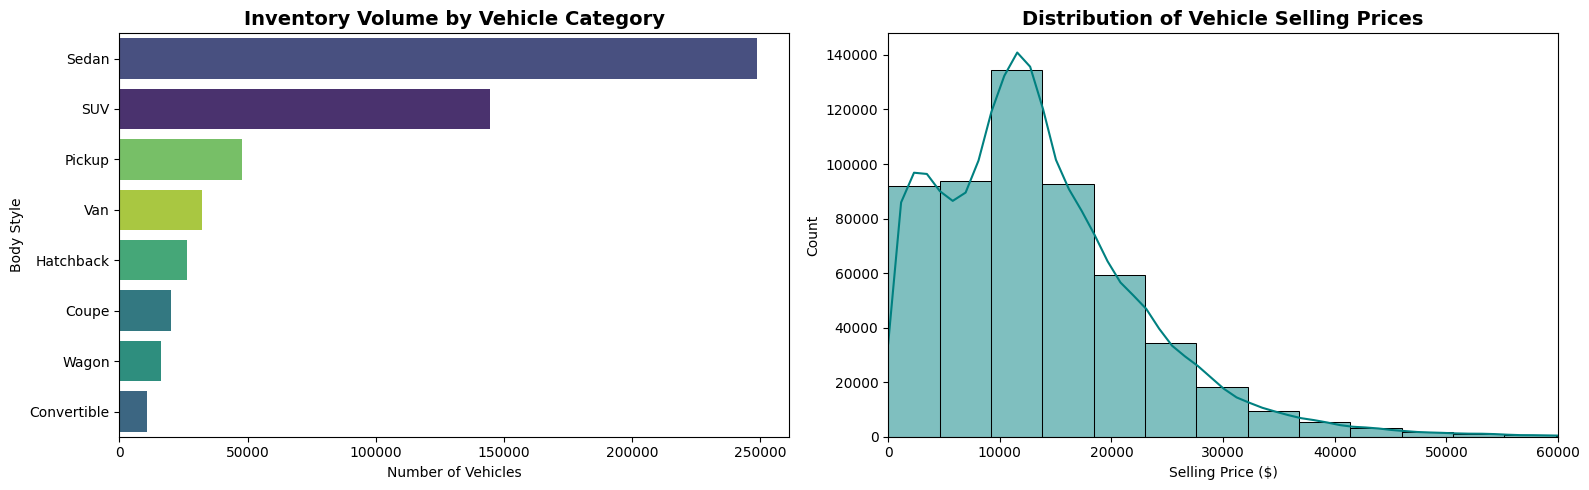

<Figure size 640x480 with 0 Axes>

In [46]:
# --- STEP 7: MARKET OVERVIEW VISUALIZATIONS ---
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Chart 1: Market Share by Cleaned Body Style (FIXED)
sns.countplot(
    ax=axes[0], 
    data=df, 
    y='Body', 
    order=df['Body'].value_counts().index, 
    palette='viridis',
    hue='Body',        # <--- This fixes the warning
    legend=False       # <--- Prevents an unnecessary legend box
)
axes[0].set_title('Inventory Volume by Vehicle Category', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Vehicles')
axes[0].set_ylabel('Body Style')

# Chart 2: Price Distribution 
sns.histplot(ax=axes[1], data=df, x='SellingPrice', bins=50, kde=True, color='teal')
axes[1].set_title('Distribution of Vehicle Selling Prices', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Selling Price ($)')
axes[1].set_xlim(0, 60000) # Capping at 60k to cut out crazy outliers

plt.tight_layout()
plt.show()
# Chart 2: Price Distribution (Checking for a bell curve)
sns.histplot(ax=axes[1], data=df, x='SellingPrice', bins=50, kde=True, color='teal')
axes[1].set_title('Distribution of Vehicle Selling Prices', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Selling Price ($)')
axes[1].set_xlim(0, 60000) # Capping at 60k to cut out crazy outliers

plt.tight_layout()
plt.show()

### 📉 Step 8: Bivariate Analysis (Value Drivers)
Analyzing how independent variables (`Odometer` and `ConditionValue`) directly impact our dependent variable (`SellingPrice`). This establishes our baseline depreciation curves.

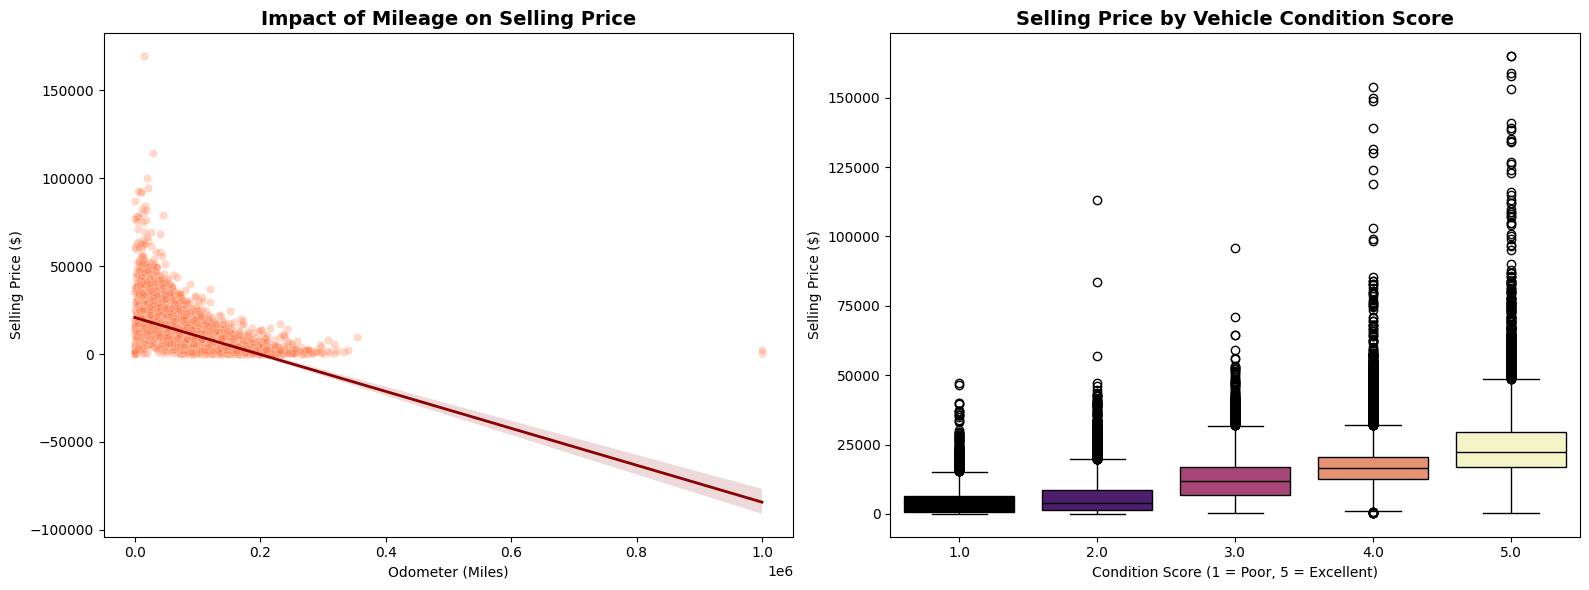

In [47]:
# --- STEP 8: BIVARIATE ANALYSIS (RELATIONSHIPS) ---
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Price vs. Mileage (Odometer)
# We use a random sample of 10,000 cars. Plotting 100,000+ dots creates a solid block of color where you can't see trends!
sample_df = df.sample(n=min(10000, len(df)), random_state=42)

sns.scatterplot(ax=axes[0], data=sample_df, x='Odometer', y='SellingPrice', alpha=0.3, color='coral')
# Adding a trendline (regression line) to clearly show the depreciation curve
sns.regplot(ax=axes[0], data=sample_df, x='Odometer', y='SellingPrice', scatter=False, color='darkred', line_kws={"linewidth": 2})

axes[0].set_title('Impact of Mileage on Selling Price', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Odometer (Miles)')
axes[0].set_ylabel('Selling Price ($)')

# Chart 2: Price vs. Vehicle Condition
# Condition scores are continuous (e.g., 3.4, 4.1), but rounding them makes for a much cleaner boxplot
df['Condition_Rounded'] = df['ConditionValue'].round()

# Filter for standard condition ranges (1 to 5) just in case weird outliers remain
valid_conditions = df[df['Condition_Rounded'].between(1, 5)]

sns.boxplot(
    ax=axes[1], 
    data=valid_conditions, 
    x='Condition_Rounded', 
    y='SellingPrice', 
    palette='magma', 
    hue='Condition_Rounded', 
    legend=False
)
axes[1].set_title('Selling Price by Vehicle Condition Score', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Condition Score (1 = Poor, 5 = Excellent)')
axes[1].set_ylabel('Selling Price ($)')

plt.tight_layout()
plt.show()

### 📈 Step 9: Executive KPI Dashboard (Multivariate)
Synthesizing market performance. We introduce `Market_Delta` (Selling Price - MMR) to evaluate which brands and body styles consistently outperform their market estimates, and track these trends chronologically.

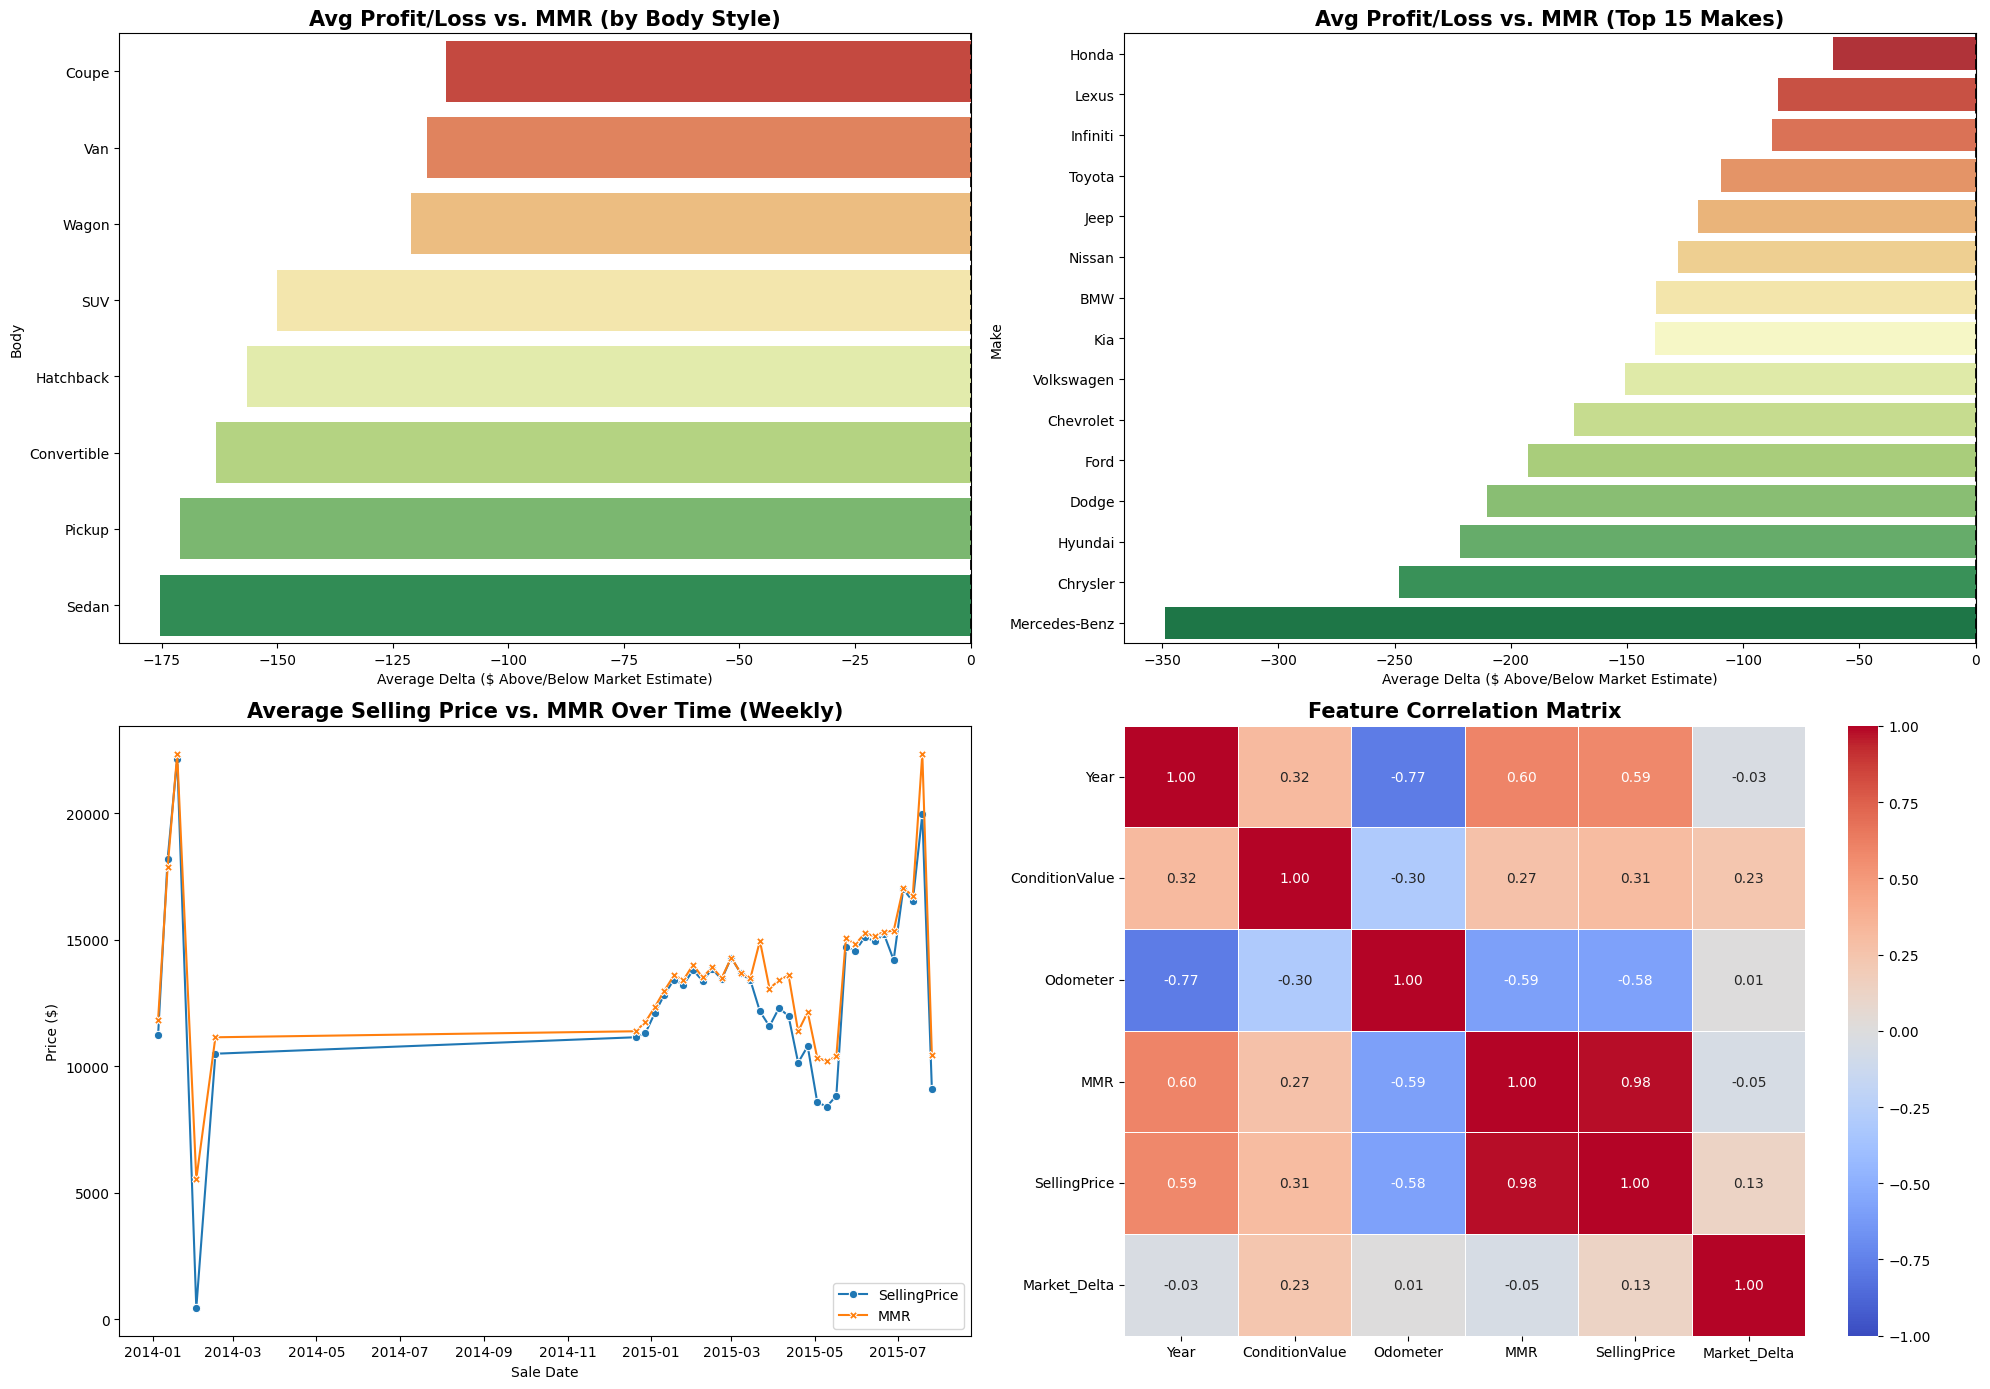

In [48]:
# --- STEP 9: ADVANCED MULTIVARIATE & KPI DASHBOARD ---
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Ensure SaleDate is recognized as a DateTime object for time-series analysis
# 'coerce' turns any weird corrupted dates into NaT (Not a Time) so it doesn't crash
df['SaleDate'] = pd.to_datetime(df['SaleDate'], utc=True, errors='coerce')

fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# --- Chart 1: Market Delta by Body Style ---
body_delta = df.groupby('Body')['Market_Delta'].mean().sort_values(ascending=False).reset_index()
sns.barplot(
    ax=axes[0, 0], data=body_delta, x='Market_Delta', y='Body', 
    hue='Body', palette='RdYlGn', legend=False
)
axes[0, 0].axvline(0, color='black', linestyle='--', linewidth=2)
axes[0, 0].set_title('Avg Profit/Loss vs. MMR (by Body Style)', fontsize=15, fontweight='bold')
axes[0, 0].set_xlabel('Average Delta ($ Above/Below Market Estimate)')

# --- Chart 2: Market Delta by Top 15 Brands ---
# We filter for the top 15 highest-volume makes so we don't look at weird 1-off cars
top_makes = df['Make'].value_counts().nlargest(15).index 
make_delta = df[df['Make'].isin(top_makes)].groupby('Make')['Market_Delta'].mean().sort_values(ascending=False).reset_index()

sns.barplot(
    ax=axes[0, 1], data=make_delta, x='Market_Delta', y='Make', 
    hue='Make', palette='RdYlGn', legend=False
)
axes[0, 1].axvline(0, color='black', linestyle='--', linewidth=2)
axes[0, 1].set_title('Avg Profit/Loss vs. MMR (Top 15 Makes)', fontsize=15, fontweight='bold')
axes[0, 1].set_xlabel('Average Delta ($ Above/Below Market Estimate)')

# --- Chart 3: Pricing Trends Over Time ---
# Group by Week ('W') to smooth out the daily noise of the auction block
time_df = df.set_index('SaleDate').resample('W')[['SellingPrice', 'MMR']].mean().dropna()
sns.lineplot(ax=axes[1, 0], data=time_df, markers=True, dashes=False, palette=['#1f77b4', '#ff7f0e'])
axes[1, 0].set_title('Average Selling Price vs. MMR Over Time (Weekly)', fontsize=15, fontweight='bold')
axes[1, 0].set_xlabel('Sale Date')
axes[1, 0].set_ylabel('Price ($)')

# --- Chart 4: Feature Correlation Heatmap ---
# What numeric features affect each other the most?
numeric_cols = df[['Year', 'ConditionValue', 'Odometer', 'MMR', 'SellingPrice', 'Market_Delta']].dropna()
sns.heatmap(
    ax=axes[1, 1], data=numeric_cols.corr(), 
    annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1
)
axes[1, 1].set_title('Feature Correlation Matrix', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.show()

### 🕵️‍♂️ Step 10: Niche Market Deep Dives
Investigating granular market anomalies: Geographic arbitrage (State-by-State profitability), enthusiast premiums (Transmission variance), and localized market density (Price vs. Mileage clusters).

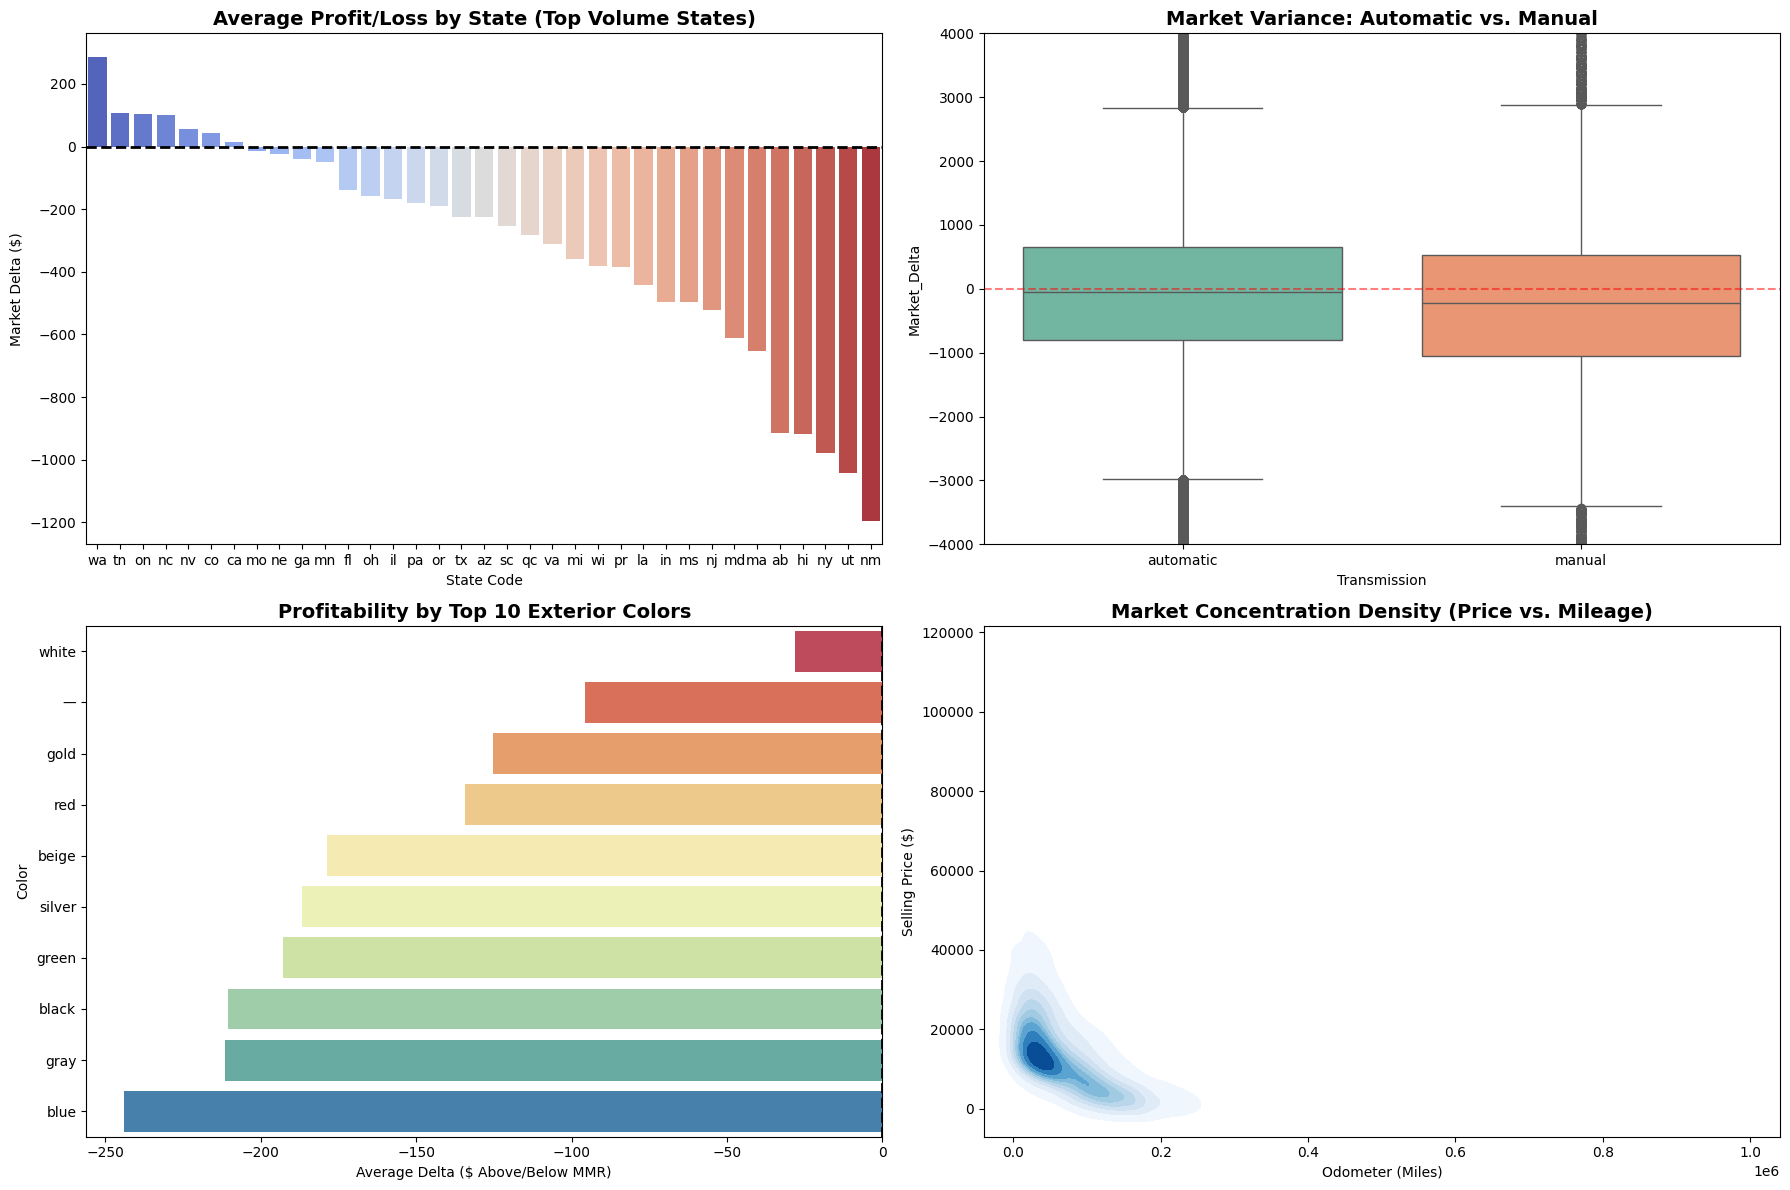

In [50]:
# --- STEP 10: NICHE MARKET DEEP DIVES ---
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# --- Chart 1: State-by-State Profitability ---
# We filter for states that have at least 100 car sales so we don't get skewed by 1 lucky car in a random state.
state_counts = df['State'].value_counts()
top_states = state_counts[state_counts > 100].index
state_data = df[df['State'].isin(top_states)]
state_delta = state_data.groupby('State')['Market_Delta'].mean().sort_values(ascending=False).reset_index()

sns.barplot(
    ax=axes[0, 0], data=state_delta, x='State', y='Market_Delta', 
    palette='coolwarm', hue='State', legend=False
)
axes[0, 0].axhline(0, color='black', linestyle='--', linewidth=2)
axes[0, 0].set_title('Average Profit/Loss by State (Top Volume States)', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Market Delta ($)')
axes[0, 0].set_xlabel('State Code')

# --- Chart 2: The "Enthusiast" Premium (Transmission) ---
# A boxplot to see the spread of profit margins based on transmission type
sns.boxplot(
    ax=axes[0, 1], data=df, x='Transmission', y='Market_Delta', 
    palette='Set2', hue='Transmission', legend=False
)
axes[0, 1].set_title('Market Variance: Automatic vs. Manual', fontsize=14, fontweight='bold')
axes[0, 1].set_ylim(-4000, 4000) # Capping the Y-axis to cut out extreme million-dollar outliers
axes[0, 1].axhline(0, color='red', linestyle='--', alpha=0.5)

# --- Chart 3: Does Color Matter? ---
# Taking the Top 10 most common colors and checking their profitability
top_colors = df['Color'].value_counts().nlargest(10).index
color_data = df[df['Color'].isin(top_colors)]
color_delta = color_data.groupby('Color')['Market_Delta'].mean().sort_values(ascending=False).reset_index()

sns.barplot(
    ax=axes[1, 0], data=color_delta, x='Market_Delta', y='Color', 
    palette='Spectral', hue='Color', legend=False
)
axes[1, 0].axvline(0, color='black', linestyle='--', linewidth=2)
axes[1, 0].set_title('Profitability by Top 10 Exterior Colors', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Average Delta ($ Above/Below MMR)')

# --- Chart 4: Market Concentration (2D Density Plot) ---
# Instead of dots, we use a KDE plot to show the "Heat" of where most cars actually sit in the market
sample_density = df.sample(n=min(5000, len(df)), random_state=42) # Sample for faster rendering
sns.kdeplot(
    ax=axes[1, 1], data=sample_density, x='Odometer', y='SellingPrice', 
    cmap='Blues', fill=True, thresh=0.05
)
axes[1, 1].set_title('Market Concentration Density (Price vs. Mileage)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Odometer (Miles)')
axes[1, 1].set_ylabel('Selling Price ($)')

plt.tight_layout()
plt.show()